In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import tensorflow as tf

In [2]:
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import load_img, img_to_array, ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.python.ops.numpy_ops import np_utils
from sklearn.metrics import classification_report, log_loss, accuracy_score
from sklearn.model_selection import train_test_split
from tensorflow.keras.optimizers import Adam
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import cv2
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, Dropout, Flatten, Dense, MaxPool2D
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.initializers import glorot_uniform
from tensorflow.keras.optimizers import Adam, SGD
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from tensorflow.keras.regularizers import l2
import tensorflow as tf
import pandas as pd

In [3]:
dir_sp_train = r"dataset/spiral/training"
dir_sp_test = r"dataset/spiral/testing"
dir_wv_train = r"dataset/wave/training"
dir_wv_test = r"dataset/wave/testing"

In [4]:
Name = []
for file in os.listdir(dir_sp_train):
    Name += [file]
print(Name)

['healthy', 'parkinson']


In [5]:
N = []
for i in range(len(Name)):
    N += [i]

normal_mapping = dict(zip(Name, N))
reverse_mapping = dict(zip(N, Name))

def mapper(value):
    return reverse_mapping[value]

In [20]:
import os
from tensorflow.keras.preprocessing.image import load_img, img_to_array

dataset_sp = []
for file in os.listdir(dir_sp_train):
    label = normal_mapping[file]  # Get class index (0 for 'healthy', 1 for 'parkinson')
    path = os.path.join(dir_sp_train, file)
    for im in os.listdir(path):
        image = load_img(os.path.join(path, im), color_mode='rgb', target_size=(100,100))
        image = img_to_array(image)
        image = image/255.0
        dataset_sp.append([image, label])

testset_sp = []
for file in os.listdir(dir_sp_test):
    label = normal_mapping[file]  # Get class index (0 for 'healthy', 1 for 'parkinson')
    path = os.path.join(dir_sp_test, file)
    for im in os.listdir(path):
        image = load_img(os.path.join(path, im), color_mode='rgb', target_size=(100,100))
        image = img_to_array(image)
        image = image/255.0
        testset_sp.append([image, label])

In [23]:
dataset_wv = []
for file in os.listdir(dir_wv_train):
    label = normal_mapping[file]  # Get class index (0 for 'healthy', 1 for 'parkinson')
    path = os.path.join(dir_wv_train, file)
    for im in os.listdir(path):
        image = load_img(os.path.join(path, im), color_mode='rgb', target_size=(100,100))
        image = img_to_array(image)
        image = image/255.0
        dataset_wv.append([image, label])

testset_wv = []
for file in os.listdir(dir_wv_test):
    label = normal_mapping[file]  # Get class index (0 for 'healthy', 1 for 'parkinson')
    path = os.path.join(dir_wv_test, file)
    for im in os.listdir(path):
        image = load_img(os.path.join(path, im), color_mode='rgb', target_size=(100,100))
        image = img_to_array(image)
        image = image/255.0
        testset_wv.append([image, label])

In [26]:
data_sp, labels_sp0 = zip(*dataset_sp)
test_sp, tlabels_sp0 = zip(*testset_sp)

data_wv, labels_wv0 = zip(*dataset_wv)
test_wv, tlabels_wv0 = zip(*testset_wv)

In [27]:
labels_sp1 = to_categorical(labels_sp0)
data_sp = np.array(data_sp)
labels_sp = np.array(labels_sp1)

tlabels_sp1 = to_categorical(tlabels_sp0)
test_sp = np.array(test_sp)
tlabels_sp = np.array(tlabels_sp1)

In [29]:
labels_wv1 = to_categorical(labels_wv0)
data_wv = np.array(data_wv)
labels_wv = np.array(labels_wv1)

tlabels_wv1 = to_categorical(tlabels_wv0)
test_wv = np.array(test_wv)
tlabels_wv = np.array(tlabels_wv1)

In [30]:
trainx_sp, testx_sp, trainy_sp, testy_sp = train_test_split(data_sp, labels_sp, test_size=0.2, random_state=44)
trainx_wv, testx_wv, trainy_wv, testy_wv = train_test_split(data_wv, labels_wv, test_size=0.2, random_state=44)

In [31]:
print(trainx_sp.shape)
print(testx_sp.shape)
print(trainy_sp.shape)
print(testy_sp.shape)

(57, 100, 100, 3)
(15, 100, 100, 3)
(57, 2)
(15, 2)


In [32]:
print("CNN Model Build")
model = Sequential()

# 1st Convolutional Layer
model.add(Conv2D(filters=32, kernel_size=(5,5), activation="relu", input_shape=(100,100,3)))
model.add(MaxPool2D(pool_size=(2,2)))

# 2nd Convolutional Layer
model.add(Conv2D(filters=64, kernel_size=(5,5), activation="relu"))
model.add(MaxPool2D(pool_size=(2,2)))

# 1st Fully Connected Layer
model.add(Flatten())
model.add(Dense(units=64, activation="relu"))

# Add output Layer
model.add(Dense(units=2, activation="softmax"))

print("Model Summary")
model.summary()


CNN Model Build
Model Summary


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 96, 96, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 44, 44, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │     1,982,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,036,354 (7.77 MB)

 Trainable params: 2,036,354 (7.77 MB)

 Non-trainable params: 0 (0.00 B)

In [33]:
model.compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])

In [60]:
epoch = 30
batch_size = 32

print("Start Training", '\n')
hist_0 = model.fit(trainx_sp, trainy_sp, batch_size=batch_size, epochs=epoch, validation_data=(testx_sp, testy_sp))
hist_1 = model.fit(trainx_wv, trainy_wv, batch_size=batch_size, epochs=epoch, validation_data=(testx_wv, testy_wv))
print("Training End", '\n')

model.save("CNN_Model.h5")

Start Training 

Epoch 1/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 599ms/step - accuracy: 0.5592 - loss: 0.6894 - val_accuracy: 0.4000 - val_loss: 0.7014
Epoch 2/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 489ms/step - accuracy: 0.5592 - loss: 0.6894 - val_accuracy: 0.4000 - val_loss: 0.7014
Epoch 3/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 363ms/step - accuracy: 0.5488 - loss: 0.6902 - val_accuracy: 0.4000 - val_loss: 0.7015
Epoch 4/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step - accuracy: 0.5280 - loss: 0.6917 - val_accuracy: 0.4000 - val_loss: 0.7014
Epoch 5/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 0.5280 - loss: 0.6917 - val_accuracy: 0.4000 - val_loss: 0.7014
Epoch 6/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step - accuracy: 0.5384 - loss: 0.6910 - val_accuracy: 0.4000 - val_loss: 0.7015
Epoch 7/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step - accuracy: 0.5384 - loss: 0.6910 - val_accuracy: 0.4000 - val_loss: 0.7015
Epoch 8/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 301ms/step - accuracy: 0.5071 - loss: 0.6933 - val_accuracy: 0

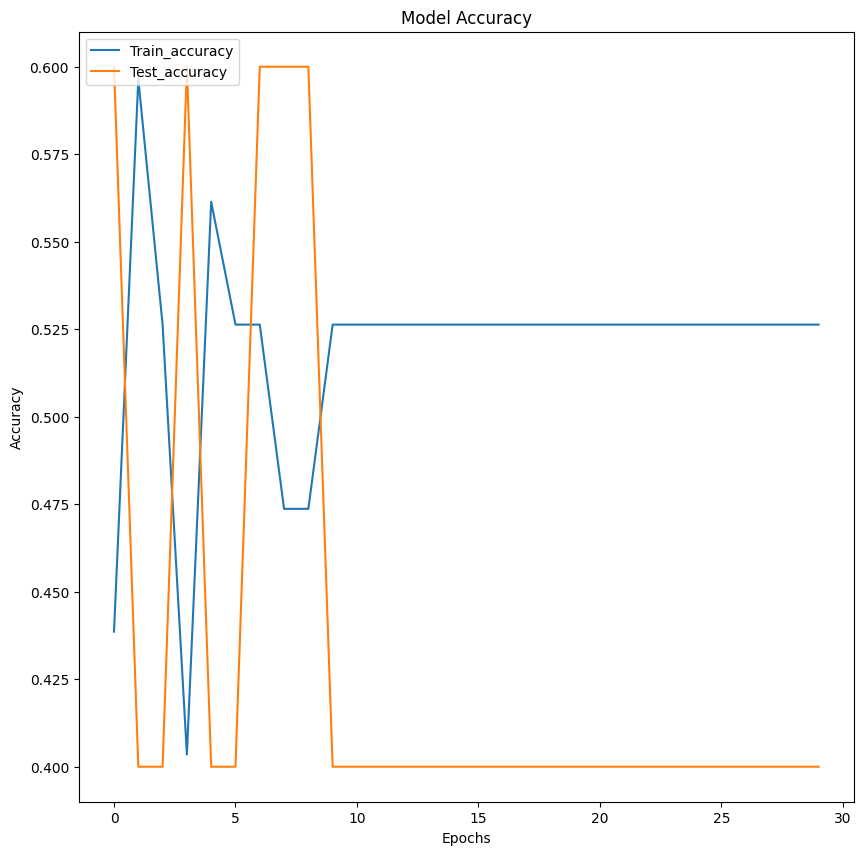

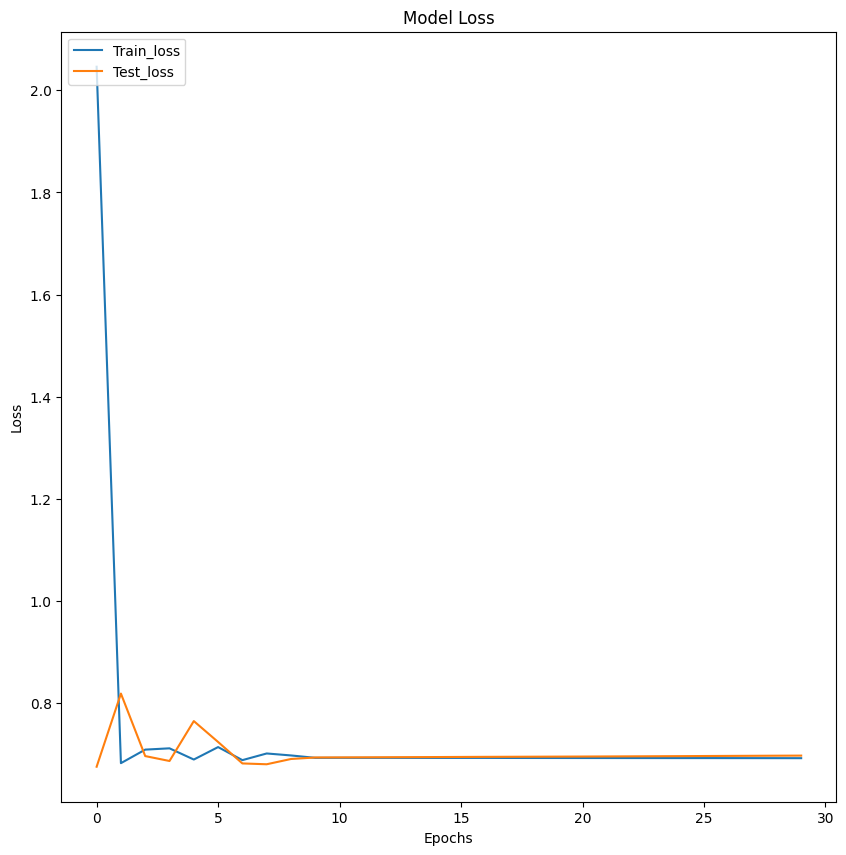

In [35]:
# Plot the training and validation accuracy
figure = plt.figure(figsize=(10, 10))
plt.plot(hist_0.history['accuracy'], label='Train_accuracy')
plt.plot(hist_0.history['val_accuracy'], label='Test_accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc="upper left")
plt.show()

# Plot the training and validation loss
figure2 = plt.figure(figsize=(10, 10))
plt.plot(hist_0.history['loss'], label='Train_loss')
plt.plot(hist_0.history['val_loss'], label='Test_loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc="upper left")
plt.show()


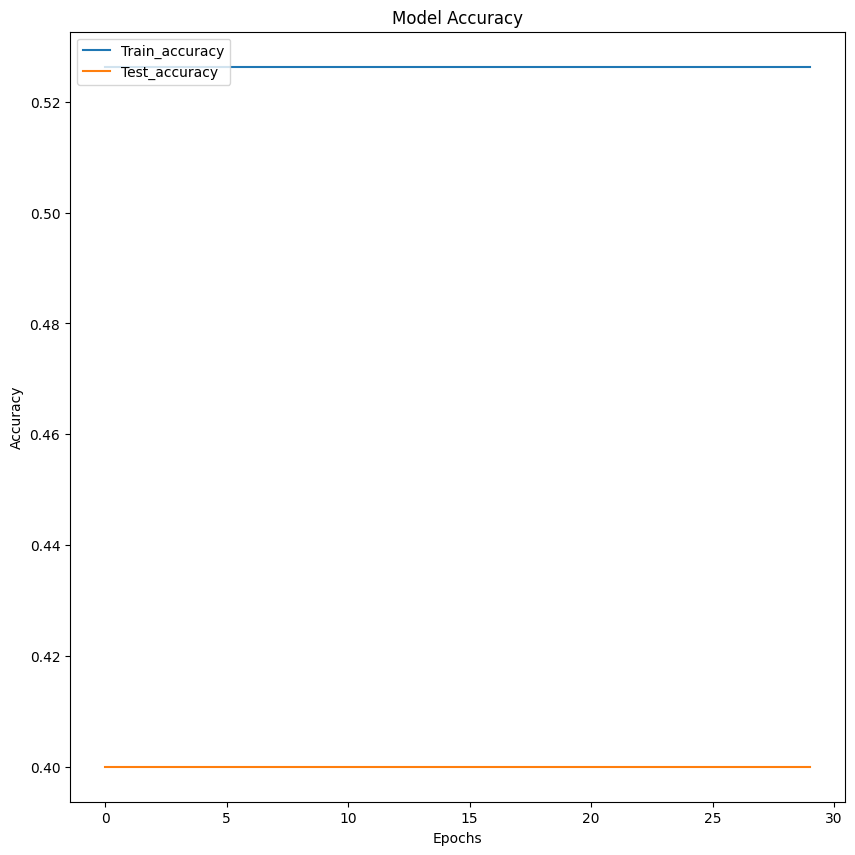

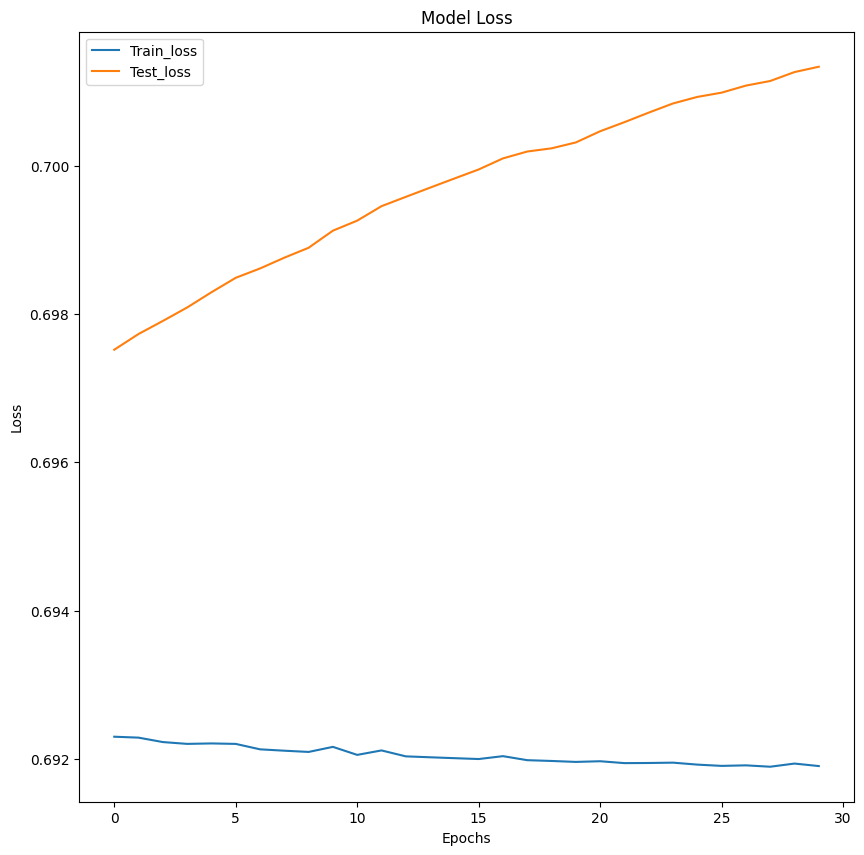

In [36]:
# Plot the training and validation accuracy
figure = plt.figure(figsize=(10, 10))
plt.plot(hist_1.history['accuracy'], label='Train_accuracy')
plt.plot(hist_1.history['val_accuracy'], label='Test_accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc="upper left")
plt.show()

# Plot the training and validation loss
figure2 = plt.figure(figsize=(10, 10))
plt.plot(hist_1.history['loss'], label='Train_loss')
plt.plot(hist_1.history['val_loss'], label='Test_loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc="upper left")
plt.show()


In [37]:
datagen = ImageDataGenerator(horizontal_flip=True, vertical_flip=True, rotation_range=20, zoom_range=0.2, width_shift_range=0.2, height_shift_range=0.2, shear_range=0.1, fill_mode="nearest")

In [38]:
pretrained_model3 = tf.keras.applications.DenseNet201(input_shape=(100, 100, 3), include_top=False, weights='imagenet', pooling='avg')
pretrained_model3.trainable = False

pretrained_model4 = tf.keras.applications.DenseNet201(input_shape=(100, 100, 3), include_top=False, weights='imagenet', pooling='avg')
pretrained_model4.trainable = False

74836368/74836368 ━━━━━━━━━━━━━━━━━━━━ 22s 0us/step


In [39]:
inputs3 = pretrained_model3.input
x3 = tf.keras.layers.Dense(128, activation='relu')(pretrained_model3.output)
outputs3 = tf.keras.layers.Dense(2, activation='softmax')(x3)
model3 = tf.keras.Model(inputs=inputs3, outputs=outputs3)

inputs4 = pretrained_model4.input
x4 = tf.keras.layers.Dense(128, activation='relu')(pretrained_model4.output)
outputs4 = tf.keras.layers.Dense(2, activation='softmax')(x4)
model4 = tf.keras.Model(inputs=inputs4, outputs=outputs4)

In [40]:
model3.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model4.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [41]:
sp_3 = model3.fit(datagen.flow(trainx_sp, trainy_sp, batch_size=32), validation_data=(testx_sp, testy_sp), epochs=100)
wv_4 = model4.fit(datagen.flow(trainx_wv, trainy_wv, batch_size=32), validation_data=(testx_wv, testy_wv), epochs=100)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 55s 20s/step - accuracy: 0.4491 - loss: 1.5097 - val_accuracy: 0.4000 - val_loss: 1.2402
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step - accuracy: 0.5860 - loss: 0.8851 - val_accuracy: 0.6000 - val_loss: 0.6144
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.5525 - loss: 0.7127 - val_accuracy: 0.6667 - val_loss: 0.6466
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step - accuracy: 0.6009 - loss: 0.7270 - val_accuracy: 0.7333 - val_loss: 0.5208
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.6578 - loss: 0.6326 - val_accuracy: 0.6667 - val_loss: 0.6928
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.7312 - loss: 0.5619 - val_accuracy: 0.6667 - val_loss: 0.6981
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 3s/step - accuracy: 0.7529 - loss: 0.5808 - val_accuracy: 0.8000 - val_loss: 0.5367
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.7663 - loss: 0.4971 - val_accuracy: 0.8000 - val_loss: 0.4503
Epoch 

In [43]:
# spiral
y_pred_sp=model3.predict(testx_sp)
pred_sp=np.argmax(y_pred_sp,axis=1)
ground_sp = np.argmax(testy_sp, axis=1)
print(classification_report(ground_sp,pred_sp))


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 613ms/step
              precision    recall  f1-score   support

           0       1.00      0.83      0.91         6
           1       0.90      1.00      0.95         9

    accuracy                           0.93        15
   macro avg       0.95      0.92      0.93        15
weighted avg       0.94      0.93      0.93        15



In [44]:
# wave
y_pred_wv=model3.predict(testx_wv)
pred_wv=np.argmax(y_pred_wv,axis=1)
ground_wv = np.argmax(testy_wv,axis=1)
print(classification_report(ground_wv,pred_wv))


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         6
           1       0.60      1.00      0.75         9

    accuracy                           0.60        15
   macro avg       0.30      0.50      0.38        15
weighted avg       0.36      0.60      0.45        15



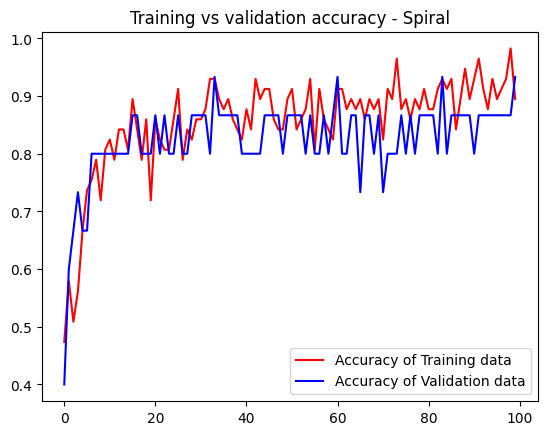

<Figure size 640x480 with 0 Axes>

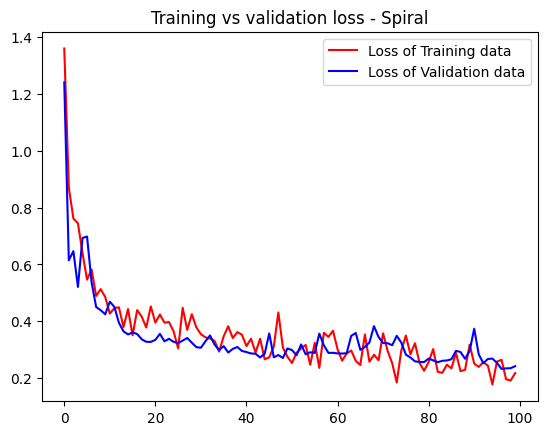

<Figure size 640x480 with 0 Axes>

In [45]:
get_acc3 = sp_3.history['accuracy']
value_acc3 = sp_3.history['val_accuracy']
get_loss3 = sp_3.history['loss']
validation_loss3 = sp_3.history['val_loss']


epochs3 = range(len(get_acc3))
plt.plot(epochs3, get_acc3, 'r', label='Accuracy of Training data')
plt.plot(epochs3, value_acc3, 'b', label='Accuracy of Validation data')
plt.title('Training vs validation accuracy - Spiral')
plt.legend(loc=0)
plt.figure()
plt.show()

epochs3 = range(len(get_loss3))
plt.plot(epochs3, get_loss3, 'r', label='Loss of Training data')
plt.plot(epochs3, validation_loss3, 'b', label='Loss of Validation data')
plt.title('Training vs validation loss - Spiral')
plt.legend(loc=0)
plt.figure()
plt.show()


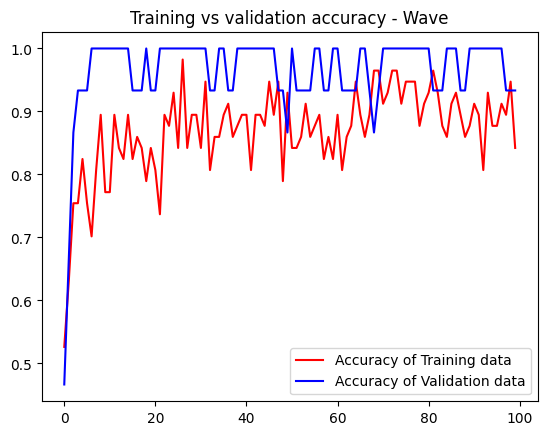

<Figure size 640x480 with 0 Axes>

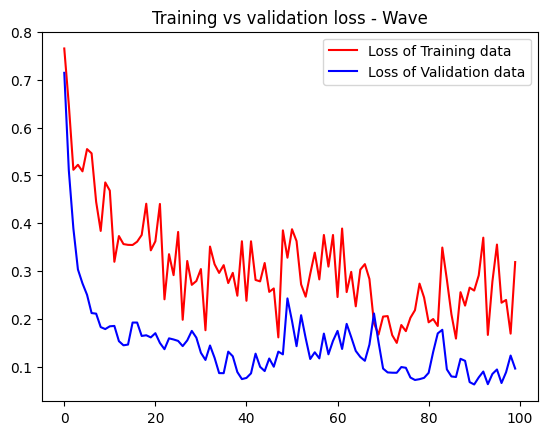

<Figure size 640x480 with 0 Axes>

In [46]:
get_acc4 = wv_4.history['accuracy']
value_acc4 = wv_4.history['val_accuracy']
get_loss4 = wv_4.history['loss']
validation_loss4 = wv_4.history['val_loss']


epochs4 = range(len(get_acc4))
plt.plot(epochs4, get_acc4, 'r', label='Accuracy of Training data')
plt.plot(epochs4, value_acc4, 'b', label='Accuracy of Validation data')
plt.title('Training vs validation accuracy - Wave')
plt.legend(loc=0)
plt.figure()
plt.show()

epochs4 = range(len(get_loss4))
plt.plot(epochs4, get_loss4, 'r', label='Loss of Training data')
plt.plot(epochs4, validation_loss4, 'b', label='Loss of Validation data')
plt.title('Training vs validation loss - Wave')
plt.legend(loc=0)
plt.figure()
plt.show()


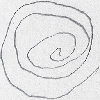

In [89]:
image1 = load_img(r"dataset/spiral/testing/parkinson/V09PE01.png", target_size=(100,100))
image1

In [90]:
image1=img_to_array(image1)
image1=image/255.0
prediction_image=np.array(image1)
prediction_image=np.expand_dims(image, axis=0)

prediction=model3.predict(prediction_image)
value=np.argmax(prediction)
move_name=mapper(value)
print("Prediction is {}.".format(move_name))



1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Prediction is healthy.


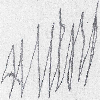

In [83]:
image2 = load_img(r"dataset/wave/testing/parkinson/V09PO01.png", target_size=(100,100))
image2

In [84]:
image2=img_to_array(image2)
image2=image2/255.0
prediction_image2=np.array(image2)
prediction_image2=np.expand_dims(image2, axis=0)

prediction2=model4.predict(prediction_image2)
value2=np.argmax(prediction2)
move_name2=mapper(value2)
print("Prediction is {}.".format(move_name2))



1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Prediction is parkinson.


In [56]:
print(test_sp.shape)
prediction_sp=model3.predict(test_sp)
print(prediction_sp.shape)

PRED_sp=[]
for item in prediction_sp:
    value_sp=np.argmax(item)
    PRED_sp+=[value_sp]

ANS_sp=tlabels_sp0
accuracy_sp=accuracy_score(ANS_sp, PRED_sp)
print(accuracy_sp)


(30, 100, 100, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
(30, 2)
0.8


In [57]:
print(test_wv.shape)
prediction_wv=model4.predict(test_wv)
print(prediction_wv.shape)

PRED_wv=[]
for item in prediction_wv:
    value_wv=np.argmax(item)
    PRED_wv+=[value_wv]

ANS_wv=tlabels_wv0
accuracy_wv=accuracy_score(ANS_wv, PRED_wv)
print(accuracy_wv)


(30, 100, 100, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step
(30, 2)
0.8333333333333334


In [87]:
# Check class distribution
from collections import Counter
print("Spiral Training Labels:", Counter(labels_sp0))
print("Spiral Test Labels:", Counter(tlabels_sp0))

Spiral Training Labels: Counter({0: 36, 1: 36})
Spiral Test Labels: Counter({0: 15, 1: 15})


In [88]:
# Check class distribution
from collections import Counter
print("Wave Training Labels:", Counter(labels_wv0))
print("Wave Test Labels:", Counter(tlabels_wv0))

Wave Training Labels: Counter({0: 36, 1: 36})
Wave Test Labels: Counter({0: 15, 1: 15})
